보팅 배깅 부스팅


프로젝트 작업 범이가 어느정도가 될지....

'
정량 결과표


보팅 후보...

보팅 레그레이써!
파이프라인 만들진 않음, 이미 각 학습 객체들에 파이프라인 있으니까,


## #03 보팅 모델 적합
추정기, 이름들 지어주고... 순서는 상관 없음
가중치를 똑같이 주겠다!



결과해석은...?
보팅은 여러개가 섞여있으니까 결과 해석의 대상이 아님...
이미 섞인 그 3가지에 대해 개별 설명을 하고 들어왔었어야함...

방향성, 영향력,,,,, 따로 정리해줘야해


섞는게 더 좋아지느냐?
배깅, 부스팅이 더 좋아지느냐> 까지 비교해서
최종 앙상블 모형 골라야함




# [LAB 08] 지도학습 > 예측 > 앙상블> 01.Voting

## #01. 보팅(Voting) 개요
- 일반적으로 단일 학습 모델을 사용하면 충분한 성능을 확보하기 어렵다.
- 이러한 부분을 보완하기 위해 여러개의 학습 모델을 생성하고
- 그 예측을 결합함으로써 보다 정확한 최종 예측을 도출하는 기법
- 앙상블은 보팅,배깅,부스팅으로 구분된다
- 각각의 알고리즘이 원본 데이터를 그대로 사용하여 각자 분석을 수행하고, 결과를 어떻게 종합하느냐에 따라 하드 보팅과 소프트 보팅으로 나눠진다

### [1] 보팅 방식의 구분
#### (1) 하드 보팅
- 각 서브 샘플에서 예측된 값을 종합하고, 최빈값으로 최종 예측값 결정
- 각각의 알고리즘이 예측한 결과값에서 다수결로 결정된 값을 최종 결정값으로 정하는 방식

#### (2) 소프트 보팅
- 각 서브샘플에서 확률을 계산하고, 각 확률값을 통해서 최종 예측값을 결정함

*여기서 클래스는 분류할 범주

| 구분       | Hard Voting | Soft Voting |
| -------- | ----------- | ----------- |
| 사용 정보    | 예측 클래스 (각 모델이 선택한 최종 범주)      | 예측 확률 (각 클래스에 속할 가능성)      |
| 결정 방식    | 다수결         | 확률 평균       |
| 모델 확신 반영 | ❌           | ⭕           |
| 성능       | 보통          | **더 좋음**    |
| 조건       | 아무 분류기 가능   | 확률 출력 필요    |



#### (3) sklearn 에서 지원하는 voting 알고리즘
- VotingClassifier
- VotingRegressor




## #01.준비 작업
### [1] 패키지 가져오기

In [123]:
from hossam import *

from pandas import DataFrame, merge
from matplotlib import pyplot as plt
import seaborn as sb
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve
from sklearn.preprocessing import StandardScaler

# 성능 평가 지표 모듈
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
)

# 보팅 회귀
from sklearn.ensemble import VotingRegressor

from sklearn.linear_model import LinearRegression, Ridge, ElasticNet


### [2] 성능 평가 함수
#### VIF 필터링 클래스

In [124]:
from IPython.display import display
from sklearn.base import BaseEstimator, TransformerMixin
from pandas import DataFrame
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor


class VIFSelector(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=10.0, check_cols=None):
        self.threshold = threshold
        self.check_cols = check_cols

    def _compute_vifs(self, X: DataFrame):
        exog = sm.add_constant(X, prepend=True)

        vifs = {}
        for i, col in enumerate(X.columns):
            try:
                vifs[col] = float(variance_inflation_factor(exog.values, i + 1))
            except Exception:
                vifs[col] = float("inf")

        vdf = DataFrame(vifs.items(), columns=["Variable", "VIF"])
        return vdf.sort_values("VIF", ascending=False)

    def fit(self, X, y=None):
        df = X.copy().dropna()

        self.vif_cols_ = self.check_cols if self.check_cols else df.columns.tolist()
        X_vif = df[self.vif_cols_].copy()

        self.drop_cols_ = []
        i = 0

        while True:
            if X_vif.shape[1] == 0:
                break

            print(f"\nVIF 제거 반복 {i+1}회차 =================")
            vdf = self._compute_vifs(X_vif)
            max_vif = vdf.iloc[0]["VIF"]
            max_col = vdf.iloc[0]["Variable"]

            if max_vif <= self.threshold:
                print(
                    "모든 변수의 VIF가 임계값 이하가 되어 종료합니다. 제거된 변수 {}개".format(
                        i
                    )
                )
                break

            X_vif = X_vif.drop(columns=[max_col])
            self.drop_cols_.append(max_col)
            print(f"제거된 변수: {max_col} (VIF={max_vif:.2f})")
            i += 1

        return self

    def transform(self, X):
        return X.drop(columns=self.drop_cols_, errors="ignore")


#### 성능 평가 함수

In [125]:
def hs_get_scores(estimator, x_test, y_true):
    if hasattr(estimator, "named_steps"):
        classname = estimator.named_steps["model"].__class__.__name__
    else:
        classname = estimator.__class__.__name__

    y_pred = estimator.predict(x_test)

    return DataFrame(
        {
            "결정계수(R2)": r2_score(y_true, y_pred),
            "평균절대오차(MAE)": mean_absolute_error(y_true, y_pred),
            "평균제곱오차(MSE)": mean_squared_error(y_true, y_pred),
            "평균오차(RMSE)": np.sqrt(mean_squared_error(y_true, y_pred)),
            "평균 절대 백분오차 비율(MAPE)": mean_absolute_percentage_error(
                y_true, y_pred
            ),
            "평균 비율 오차(MPE)": np.mean((y_true - y_pred) / y_true * 100),
        },
        index=[classname],
    )

#

#### 과적합 판정 함수

##### 별도추가

In [126]:
import matplotlib.pyplot as plt

my_dpi = 100  # 없으면 기본값

def create_figure(figsize=(1280/100, 720/100), dpi=None):
    if dpi is None:
        dpi = my_dpi
    fig, ax = plt.subplots(1, 1, figsize=figsize, dpi=dpi)
    return fig, ax

def finalize_plot(ax):
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    plt.close()


In [127]:
def hs_learning_cv(
    estimator, x, y, scoring="neg_root_mean_squared_error",
    cv=5, train_sizes=np.linspace(0.1, 1.0, 10), n_jobs=-1
):

    train_sizes, train_scores, cv_scores = learning_curve(  # type: ignore
        estimator=estimator,
        X=x,
        y=y,
        train_sizes=train_sizes,
        cv=cv,
        scoring=scoring,
        n_jobs=n_jobs,
        shuffle=True,
        random_state=52,
    )

    if hasattr(estimator, "named_steps"):
        classname = estimator.named_steps["model"].__class__.__name__
    else:
        classname = estimator.__class__.__name__

    # neg RMSE -> RMSE
    train_rmse = -train_scores
    cv_rmse = -cv_scores

    # 평균 / 표준편차
    train_mean = train_rmse.mean(axis=1)
    cv_mean = cv_rmse.mean(axis=1)
    cv_std = cv_rmse.std(axis=1)

    # 마지막 지점 기준 정량 판정
    final_train = train_mean[-1]
    final_cv = cv_mean[-1]
    final_std = cv_std[-1]

    gap_ratio = final_train / final_cv
    var_ratio = final_std / final_cv

    # -------------------------
    # 과소적합 기준선 (some_threshold)
    # -------------------------

    # 기준모형 RMSE (평균 예측)
    y_mean = y.mean()
    rmse_naive = np.sqrt(np.mean((y - y_mean) ** 2))

    # 분산 기반
    std_y = y.std()

    # 최소 설명력(R2) 기반
    min_r2 = 0.10
    rmse_r2 = np.sqrt((1 - min_r2) * np.var(y))

    # 최종 threshold (가장 관대한 기준)
    # → 원래 some_threshold는 도메인 지식 수준에서 이 모델은 최소 어느 정도의 성능은 내야 한다는 기준을 설정하는 것
    some_threshold = min(rmse_naive, std_y, rmse_r2)

    # -------------------------
    # 판정 로직
    # -------------------------
    if gap_ratio >= 0.95 and final_cv > some_threshold:
        status = "⚠️ 과소적합 (bias 큼)"
    elif gap_ratio <= 0.8:
        status = "⚠️ 과대적합 (variance 큼)"
    elif gap_ratio <= 0.95 and var_ratio <= 0.10:
        status = "✅ 일반화 양호"
    elif var_ratio > 0.15:
        status = "⚠️ 데이터 부족 / 분산 큼"
    else:
        status = "⚠️ 판단 유보"

    # -------------------------
    # 정량 결과 표
    # -------------------------
    result_df = DataFrame(
        {
            "Train RMSE": [final_train],
            "CV RMSE 평균": [final_cv],
            "CV RMSE 표준편차": [final_std],
            "Train/CV 비율": [gap_ratio],
            "CV 변동성 비율": [var_ratio],
            "판정 결과": [status],
        },
        index=[classname],
    )

    # display(result_df)

    # -------------------------
    # 학습곡선 시각화
    # -------------------------

    fig, ax = create_figure()

    sb.lineplot(
        x=train_sizes,
        y=train_mean,
        marker="o",
        markeredgecolor="#ffffff",
        label="Train RMSE",
    )

    sb.lineplot(
        x=train_sizes,
        y=cv_mean,
        marker="o",
        markeredgecolor="#ffffff",
        label="Train RMSE",
    )

    ax.set_xlabel("RMSE", fontsize=8, labelpad=5)  # type: ignore
    ax.set_ylabel("학습곡선 (Learning Curve)", fontsize=8, labelpad=5)  # type: ignore
    ax.grid(True, alpha=0.3)  # type: ignore

    finalize_plot(ax)

    return result_df


#### 성능평가 + 과적합 판정 동시 수행 함수

In [128]:
def hs_get_score_cv(
    estimator,
    x_test,
    y_test,
    x_origin,
    y_origin,
    scoring="neg_root_mean_squared_error",
    cv=5,
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1,
):

    score_df = hs_get_scores(estimator, x_test, y_test)

    cv_df = hs_learning_cv(
        estimator,
        x_origin,
        y_origin,
        scoring=scoring,
        cv=cv,
        train_sizes=train_sizes,
        n_jobs=n_jobs,
    )

    return merge(score_df, cv_df, left_index=True, right_index=True)


### [3] 데이터 가져오기 + 인덱스,타입 변환

In [129]:
origin = load_data("restaurant_sales_preprocessed")
origin.set_index("date", inplace=True)
origin["holiday"] = origin["holiday"].astype("category")
origin["weekend"] = origin["weekend"].astype("category")
origin.info()


어느 식당의 1년간 일별 매출을 기록한 데이터의 전처리 완료 버전(명목형이 이진변수만 있으므로 더미변수는 처리하지 않음)
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 353 entries, 2024-01-01 to 2024-12-30
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   sales           353 non-null    float64 
 1   visitors        353 non-null    int64   
 2   avg_price       353 non-null    int64   
 3   marketing_cost  353 non-null    float64 
 4   delivery_ratio  353 non-null    float64 
 5   rain_mm         353 non-null    float64 
 6   temperature     353 non-null    float64 
 7   holiday         353 non-null    category
 8   weekend         353 non-null    category
dtypes: category(2), float64(5), int64(2)
memory usage: 23.0 KB


### [4] 훈련,학습 데이터 분리

In [130]:
df = origin

yname = "sales"
x = df.drop(columns=[yname])
y = df[yname]

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.25, random_state=52
)

x_train.shape, x_test.shape, y_train.shape, y_test.shape

((264, 8), (89, 8), (264,), (89,))

## #02. Voting 후보 선정
### [1] 지금까지 살펴본 모든 모형들의 성능



| 모델           | 결정계수(R2) |   MAE |   MSE |  RMSE |  MAPE |   MPE | Train RMSE | CV RMSE 평균 | CV RMSE 표준편차 | Train/CV 비율 | CV 변동성 비율 | 판정 결과                |
| ------------ | -------: | ----: | ----: | ----: | ----: | ----: | ---------: | ---------: | -----------: | ----------: | --------: | -------------------- |
| Linear       |    0.709 | 0.156 | 0.042 | 0.204 | 0.010 | 0.225 |      0.198 |      0.203 |        0.012 |       0.973 |     0.060 | ⚠️ 판단 유보             |
| Ridge        |    0.708 | 0.156 | 0.042 | 0.205 | 0.010 | 0.219 |      0.198 |      0.203 |        0.012 |       0.974 |     0.058 | ⚠️ 판단 유보             |
| Lasso        |    0.707 | 0.155 | 0.042 | 0.205 | 0.009 | 0.221 |      0.199 |      0.204 |        0.011 |       0.978 |     0.055 | ⚠️ 판단 유보             |
| ElasticNet   |    0.709 | 0.156 | 0.042 | 0.204 | 0.010 | 0.223 |      0.198 |      0.203 |        0.012 |       0.974 |     0.059 | ⚠️ 판단 유보             |
| SGD          |    0.700 | 0.160 | 0.043 | 0.207 | 0.010 | 0.229 |      0.203 |      0.210 |        0.010 |       0.964 |     0.046 | ⚠️ 판단 유보             |
| KNN          |    0.635 | 0.178 | 0.052 | 0.229 | 0.011 | 0.301 |      0.000 |       0.22 |        0.020 |       0.000 |     0.090 | ⚠️ 과대적합 (variance 큼) |
| DecisionTree |    0.620 | 0.196 | 0.054 | 0.233 | 0.012 | 0.353 |      0.224 |      0.245 |        0.018 |       0.912 |     0.072 | ✅ 일반화 양호             |
| SVR          |    0.701 | 0.157 | 0.043 | 0.207 | 0.010 | 0.233 |      0.196 |      0.206 |        0.011 |       0.949 |     0.055 | ✅ 일반화 양호             |



### [2] 성능표 데이터 프레임
- 실제로는 이 표를 각 모델을 학습한 결과로부터 얻어야한다
- hs_get_score_cv() 함수를 호출한 결과 데이터 프레임을 concat() 으로 묶는다


In [131]:
score_df = DataFrame(
    [
        [
            "Linear",
            0.709,
            0.156,
            0.042,
            0.204,
            0.010,
            0.225,
            0.198,
            0.203,
            0.012,
            0.973,
            0.060,
            "⚠️ 판단 유보",
        ],
        [
            "Ridge",
            0.708,
            0.156,
            0.042,
            0.205,
            0.010,
            0.219,
            0.198,
            0.203,
            0.012,
            0.974,
            0.058,
            "⚠️ 판단 유보",
        ],
        [
            "Lasso",
            0.707,
            0.155,
            0.042,
            0.205,
            0.009,
            0.221,
            0.199,
            0.204,
            0.011,
            0.978,
            0.055,
            "⚠️ 판단 유보",
        ],
        [
            "ElasticNet",
            0.709,
            0.156,
            0.042,
            0.204,
            0.010,
            0.223,
            0.198,
            0.203,
            0.012,
            0.974,
            0.059,
            "⚠️ 판단 유보",
        ],
        [
            "SGD",
            0.700,
            0.160,
            0.043,
            0.207,
            0.010,
            0.229,
            0.203,
            0.210,
            0.010,
            0.964,
            0.046,
            "⚠️ 판단 유보",
        ],
        [
            "KNN",
            0.635,
            0.178,
            0.052,
            0.229,
            0.011,
            0.301,
            0.000,
            0.220,
            0.020,
            0.000,
            0.090,
            "⚠️ 과대적합 (variance 큼)",
        ],
        [
            "DecisionTree",
            0.620,
            0.196,
            0.054,
            0.233,
            0.012,
            0.353,
            0.224,
            0.245,
            0.018,
            0.912,
            0.072,
            "✅ 일반화 양호",
        ],
        [
            "SVR",
            0.701,
            0.157,
            0.043,
            0.207,
            0.010,
            0.233,
            0.196,
            0.206,
            0.011,
            0.949,
            0.055,
            "✅ 일반화 양호",
        ],
    ],
    columns=[
        "모델",
        "결정계수(R2)",
        "MAE",
        "MSE",
        "RMSE",
        "MAPE",
        "MPE",
        "Train RMSE",
        "CV RMSE 평균",
        "CV RMSE 표준편차",
        "Train/CV 비율",
        "CV 변동성 비율",
        "판정 결과",
    ],
)
score_df

,모델,결정계수(R2),MAE,MSE,RMSE,MAPE,MPE,Train RMSE,CV RMSE 평균,CV RMSE 표준편차,Train/CV 비율,CV 변동성 비율,판정 결과
0,Linear,0.709,0.156,0.042,0.204,0.010,0.225,0.198,0.203,0.012,0.973,0.060,⚠️ 판단 유보
1,Ridge,0.708,0.156,0.042,0.205,0.010,0.219,0.198,0.203,0.012,0.974,0.058,⚠️ 판단 유보
2,Lasso,0.707,0.155,0.042,0.205,0.009,0.221,0.199,0.204,0.011,0.978,0.055,⚠️ 판단 유보
3,ElasticNet,0.709,0.156,0.042,0.204,0.010,0.223,0.198,0.203,0.012,0.974,0.059,⚠️ 판단 유보
4,SGD,0.700,0.160,0.043,0.207,0.010,0.229,0.203,0.210,0.010,0.964,0.046,⚠️ 판단 유보
5,KNN,0.635,0.178,0.052,0.229,0.011,0.301,0.000,0.220,0.020,0.000,0.090,⚠️ 과대적합 (variance 큼)
6,DecisionTree,0.620,0.196,0.054,0.233,0.012,0.353,0.224,0.245,0.018,0.912,0.072,✅ 일반화 양호
7,SVR,0.701,0.157,0.043,0.207,0.010,0.233,0.196,0.206,0.011,0.949,0.055,✅ 일반화 양호


### [3] Voting 후보 선정

| 지표         | 역할     | Voting 후보 선정에서 위치 |
| ---------- | ------ | ----------------- |
| Train RMSE | 학습 적합도 | 참고                |
| CV RMSE 평균 | 일반화 성능 | 1순위               |
| CV 변동성 비율  | 안정성    | 1순위               |
| R²         | 설명력    | 2순위               |
| RMSE / MAE | 절대 오차  | 2순위               |


In [132]:
# 1) 과대적합 모델 제거
drop_idx = score_df[score_df["판정 결과"].str.contains("과대적합")].index

# 해당 인덱스 제거
candidates = score_df.drop(drop_idx, axis=0).copy()

# 2) Train/CV 계산
candidates["Train_CV_gap"] = (candidates["Train/CV 비율"] - 1).abs()

# 3) 1순위 기준 정렬 (일반화 안정성)
candidates = candidates.sort_values(
    by=[
        "CV RMSE 평균",
        "CV 변동성 비율",
        "Train_CV_gap",
    ],
    ascending=[True, True, True],
)

# 4) 2순위 기준 정렬 (설명력·에러율)
candidates = candidates.sort_values(
    by=[
        "CV RMSE 평균",
        "CV 변동성 비율",
        "Train_CV_gap",
        "결정계수(R2)",
        "RMSE",
        "MAE",
    ],
    ascending=[True, True, True, False, True, True],
)

# 5) Voting 후보 선정
TOP_N = 3
voting_candidates = candidates.head(TOP_N)

voting_model_names = voting_candidates["모델"].tolist()

voting_candidates.drop(columns="Train_CV_gap").reset_index(drop=True)


,모델,결정계수(R2),MAE,MSE,RMSE,MAPE,MPE,Train RMSE,CV RMSE 평균,CV RMSE 표준편차,Train/CV 비율,CV 변동성 비율,판정 결과
0,Ridge,0.708,0.156,0.042,0.205,0.010,0.219,0.198,0.203,0.012,0.974,0.058,⚠️ 판단 유보
1,ElasticNet,0.709,0.156,0.042,0.204,0.010,0.223,0.198,0.203,0.012,0.974,0.059,⚠️ 판단 유보
2,Linear,0.709,0.156,0.042,0.204,0.010,0.225,0.198,0.203,0.012,0.973,0.060,⚠️ 판단 유보


### [4] 선정된 후보에 대한 학습 모델 적합

#### (1) Ridge

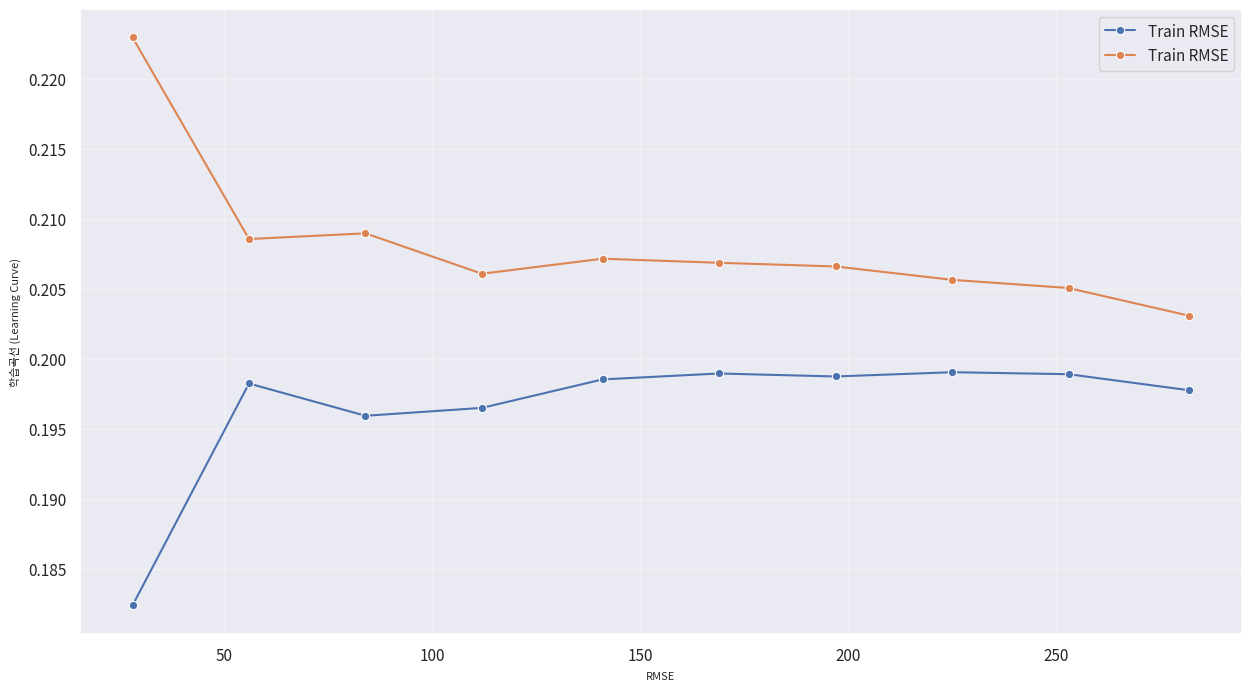

CPU times: total: 172 ms
Wall time: 201 ms


,결정계수(R2),평균절대오차(MAE),평균제곱오차(MSE),평균오차(RMSE),평균 절대 백분오차 비율(MAPE),평균 비율 오차(MPE),Train RMSE,CV RMSE 평균,CV RMSE 표준편차,Train/CV 비율,CV 변동성 비율,판정 결과
Ridge,0.708,0.156,0.042,0.205,0.010,0.219,0.198,0.203,0.012,0.974,0.058,⚠️ 판단 유보


In [133]:
%%time

# Ridge 모델정의 (n_jobs 없음)
ridge_pipe = Pipeline([("scaler", StandardScaler()), ("model", Ridge(random_state=52))])

# 탐색할 하이퍼파라미터 그리드 설정
ridge_param_grid = {"model__alpha": [0.01, 0.1, 1, 10, 100]}

# 그리드 서치 객체 생성
ridge_gs = GridSearchCV(
    estimator=ridge_pipe,
    param_grid=ridge_param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1,
)

ridge_gs.fit(x_train, y_train)
ridge_estimator = ridge_gs.best_estimator_

# 성능평가
ridge_result_df = hs_get_score_cv(ridge_estimator, x_test, y_test, x, y)

ridge_result_df


#### (2) ElasticNet

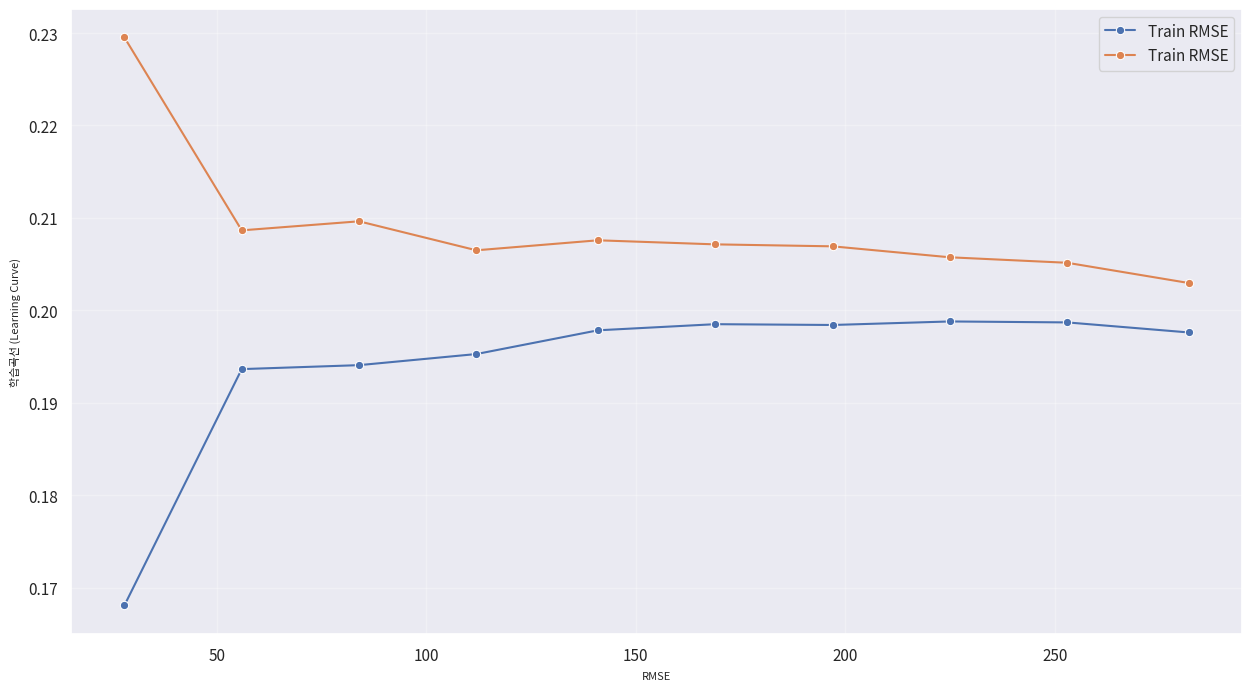

CPU times: total: 219 ms
Wall time: 248 ms


,결정계수(R2),평균절대오차(MAE),평균제곱오차(MSE),평균오차(RMSE),평균 절대 백분오차 비율(MAPE),평균 비율 오차(MPE),Train RMSE,CV RMSE 평균,CV RMSE 표준편차,Train/CV 비율,CV 변동성 비율,판정 결과
ElasticNet,0.709,0.156,0.042,0.204,0.010,0.223,0.198,0.203,0.012,0.974,0.059,⚠️ 판단 유보


In [134]:
%%time

# ElasticNet 모델정의 (n_jobs 없음)
en_pipe = Pipeline([("scaler", StandardScaler()), ("model", ElasticNet(random_state=52))])

# 탐색할 하이퍼파라미터 그리드 설정
en_param_grid = {
    "model__alpha": [0.001, 0.01, 0.1, 1, 10],
    "model__l1_ratio": [0.1, 0.5, 0.9],
}

# 그리드 서치 객체 생성
en_gs = GridSearchCV(
    estimator=en_pipe,
    param_grid=en_param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1,
)

en_gs.fit(x_train, y_train)
en_estimator = en_gs.best_estimator_

# 성능평가
en_result_df = hs_get_score_cv(en_estimator, x_test, y_test, x, y)

en_result_df


#### (3) Linear


VIF 제거 반복 1회차 =================
모든 변수의 VIF가 임계값 이하가 되어 종료합니다. 제거된 변수 0개


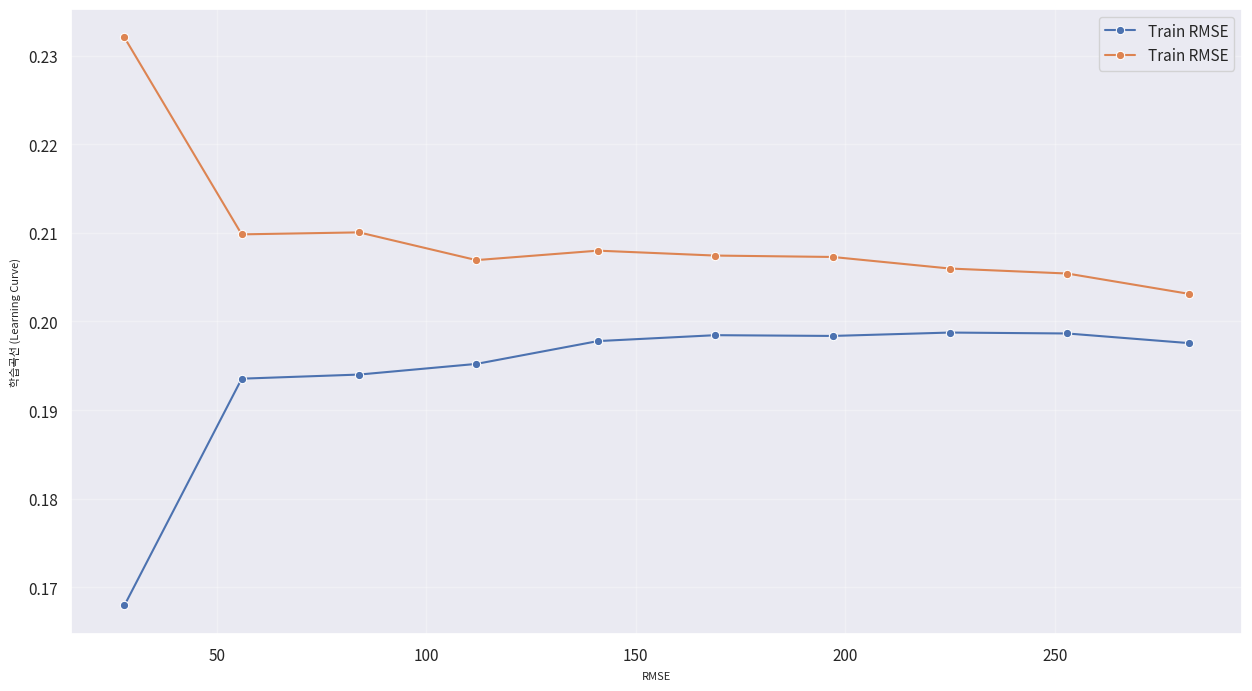

CPU times: total: 203 ms
Wall time: 718 ms


,결정계수(R2),평균절대오차(MAE),평균제곱오차(MSE),평균오차(RMSE),평균 절대 백분오차 비율(MAPE),평균 비율 오차(MPE),Train RMSE,CV RMSE 평균,CV RMSE 표준편차,Train/CV 비율,CV 변동성 비율,판정 결과
LinearRegression,0.709,0.156,0.042,0.204,0.010,0.225,0.198,0.203,0.012,0.973,0.060,⚠️ 판단 유보


In [135]:
%%time

linear_pipe = Pipeline(
    [
        (
            "vif_selector",
            VIFSelector(
                check_cols=[
                    "visitors",
                    "avg_price",
                    "marketing_cost",
                    "delivery_ratio",
                    "rain_mm",
                    "temperature",
                ]
            ),
        ),
        (
            "scaler",
            StandardScaler(),
        ),
        ("model", LinearRegression(n_jobs=-1)),
    ]
)

# 탐색할 하이퍼파라미터 그리드 설정
# 선형회귀는 하이퍼파라미터가 없음
linear_param_grid = {}

# 그리드 서치 객체 생성
linear_gs = GridSearchCV(
    estimator=linear_pipe, param_grid=linear_param_grid, cv=5, scoring="r2", n_jobs=-1
)

linear_gs.fit(x_train, y_train)

linear_estimator = linear_gs.best_estimator_

# 성능평가
linear_result_df = hs_get_score_cv(linear_estimator, x_test, y_test, x, y)

linear_result_df


## #03. Voting 모델 적합


VIF 제거 반복 1회차 =================
모든 변수의 VIF가 임계값 이하가 되어 종료합니다. 제거된 변수 0개


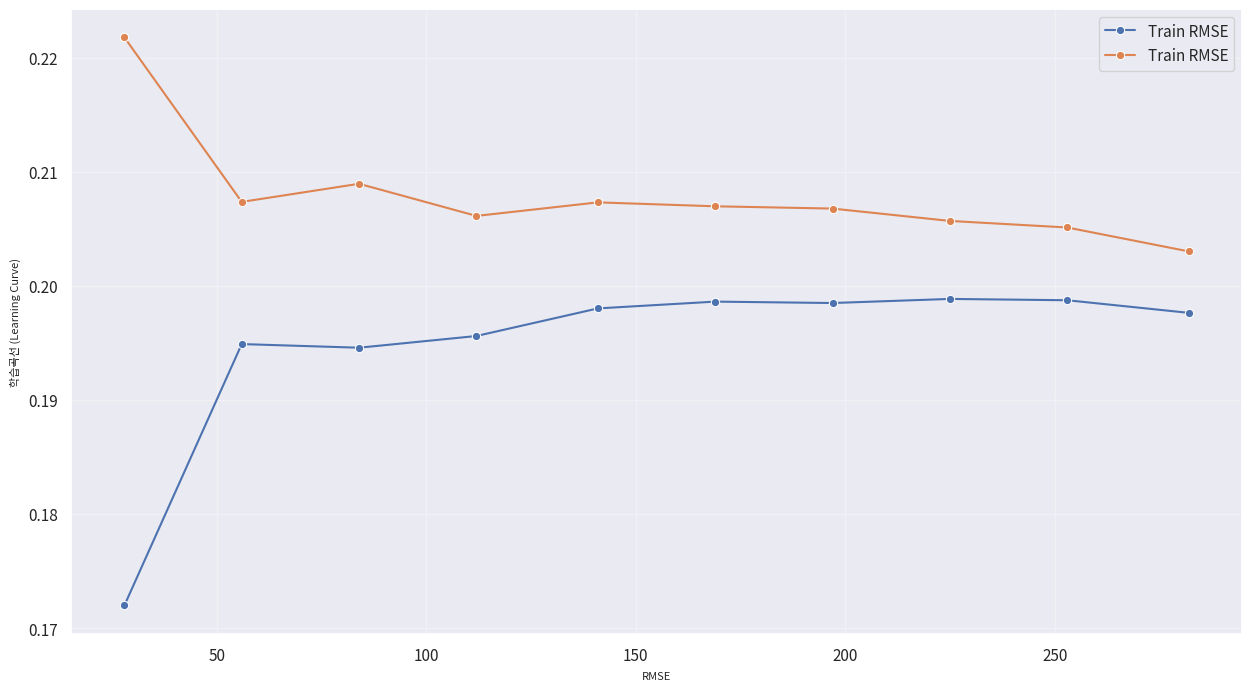

{'weights': [1, 2, 1]}

,결정계수(R2),평균절대오차(MAE),평균제곱오차(MSE),평균오차(RMSE),평균 절대 백분오차 비율(MAPE),평균 비율 오차(MPE),Train RMSE,CV RMSE 평균,CV RMSE 표준편차,Train/CV 비율,CV 변동성 비율,판정 결과
VotingRegressor,0.709,0.156,0.042,0.204,0.010,0.221,0.198,0.203,0.012,0.973,0.059,⚠️ 판단 유보


CPU times: total: 281 ms
Wall time: 456 ms


In [136]:
%%time

# ============================
# 1) VotingRegressor 정의
# ============================
voting_model = VotingRegressor(
    estimators=[
        ("linear", linear_estimator),   # VIF + Scaler + LinearRegression
        ("ridge", ridge_estimator),     # Scaler + Ridge
        ("elasticnet", en_estimator),   # Scaler + ElasticNet
    ],
    weights=[1, 1, 1],
)

# ============================
# 2) Voting 가중치 하이퍼파라미터 그리드
# ============================
voting_param_grid = {
    "weights": [
        [1, 1, 1],
        [2, 1, 1],
        [1, 2, 1],
        [1, 1, 2],
        [2, 2, 1],
        [1, 2, 2],
        [2, 1, 2],
    ]
}

# ============================
# 3) Voting GridSearchCV
# ============================
voting_gs = GridSearchCV(
    estimator=voting_model,
    param_grid=voting_param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1,
)

voting_gs.fit(x_train, y_train)

voting_estimator = voting_gs.best_estimator_
voting_best_weights = voting_gs.best_params_

# ============================
# 4) 성능평가
# ============================
voting_result_df = hs_get_score_cv(
    voting_estimator,
    x_test,
    y_test,
    x,
    y,
)

display(voting_best_weights)
display(voting_result_df)


## #04. 결과 해석

Voting은 “해석 대상 모델”이 아님
- 해석은 구성 모델에서 하고, Voting은 성능용으로만 씀
- 계수·중요도를 해석하는 모델이 아니라 예측을 평균내는 메타 모델


설명은 각 구성 모델에 대해 개별적으로 수행한다.

| 목적     | 사용 모델              | 방법         |
| ------ | ------------------ | ---------- |
| 변수 방향성 | Linear / Ridge     | 계수 부호 · 크기 |
| 변수 선택  | Lasso / ElasticNet | 계수 0 여부    |
| 비선형 영향 | SVR / Tree         | SHAP       |
| 안정성 확인 | 모든 모델              | CV RMSE    |
